<a href="https://colab.research.google.com/github/niya-c-anto/Learnings/blob/main/SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 13.3 MB/s eta 0:00:00


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import r2_score as R2
from scipy.special import softmax

In [ ]:
import shap

In [ ]:
def print_feature_importances_random_forest(random_forest_model):
# Fetch the feature importances and feature names
  importances = random_forest_model.feature_importances_
  features = random_forest_model.feature_names_in_
# Organize them in a dictionary
  feature_importances = {fea: imp for imp, fea in zip(importances,
  features)}
# Sorts the dictionary
  feature_importances = {k: v for k, v in
  sorted(feature_importances.items(), key=lambda item: item[1], reverse =
  True)}
# Prints the feature importances
  for k, v in feature_importances.items():
    print(f"{k} -> {v:.4f}")


In [ ]:
def print_feature_importances_shap_values(shap_values, features):
# Calculates the feature importance (mean absolute shap value) for each feature
  importances = []
  for i in range(shap_values.values.shape[1]):
    importances.append(np.mean(np.abs(shap_values.values[:, i])))
# Calculates the normalized version
  importances_norm = softmax(importances)
# Organize the importances and columns in a dictionary
  feature_importances = {fea: imp for imp, fea in zip(importances, features)}
  feature_importances_norm = {fea: imp for imp, fea in zip(importances_norm, features)}
# Sorts the dictionary
  feature_importances = {k: v for k, v in sorted(feature_importances.items(), key=lambda item: item[1],
  reverse = True)}
  feature_importances_norm= {k: v for k, v in sorted(feature_importances_norm.items(), key=lambda item:
  item[1], reverse = True)}
# Prints the feature importances
  for k, v in feature_importances.items():
    print(f"{k} -> {v:.4f} (softmax = {feature_importances_norm[k]:.4f})")


In [ ]:
def evaluate_regression(y, y_pred):
  '''
  Prints the most common evaluation metrics for regression
  '''
  mae = MAE(y, y_pred)
  mse = MSE(y, y_pred)
  rmse = mse ** (1/2)
  r2 = R2(y, y_pred)
  print('Regression result')
  print(f"MAE: {mae:.2f}")
  print(f"MSE: {mse:.2f}")
  print(f"RMSE: {rmse:.2f}")
  print(f"R2: {r2:.2f}")

In [ ]:
#Import a regression dataset
from sklearn.datasets import fetch_california_housing
dataset = fetch_california_housing(as_frame = True)
print(dataset['DESCR'])

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived

In [ ]:
# Gets the independent variables
X = dataset['data']
X.head(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# Checks the shape of the data
X.shape

(20640, 8)

In [ ]:
# Gets the dependent variable (the target)
y = dataset['target']
y.head(5)

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size = 0.2)


In [ ]:

# Prepares a default instance of the random forest regressor
model = RandomForestRegressor()

In [ ]:

# Fits the model on the data
model.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
# Evaluates the model
y_pred = model.predict(X_test)
evaluate_regression(y_test, y_pred)
# Prints the feature importances
print_feature_importances_random_forest(model)

Regression result
MAE: 0.32
MSE: 0.23
RMSE: 0.48
R2: 0.83
MedInc -> 0.5192
AveOccup -> 0.1375
Latitude -> 0.0955
Longitude -> 0.0906
HouseAge -> 0.0517
AveRooms -> 0.0433
Population -> 0.0326
AveBedrms -> 0.0297


In [ ]:
# Fits the explainer
explainer = shap.Explainer(model.predict, X_test)
# Calculates the SHAP values - It takes some time
shap_values = explainer(X_test)
shap_values

ExactExplainer explainer: 4129it [30:43,  2.23it/s]


.values =
array([[ 1.14454066, -0.20064178,  0.13191105, ...,  0.00961878,
         0.44750046, -0.2807229 ],
       [ 2.33639086,  0.01384241,  0.09992241, ..., -0.03018787,
        -0.05913301,  0.18096261],
       [ 0.02078516, -0.47032176,  0.10927508, ...,  0.43394708,
         0.30678627, -0.75234849],
       ...,
       [-0.24685338, -0.01511088, -0.03525917, ..., -0.37109048,
         0.32154983, -0.45950845],
       [-0.32400218, -0.00698536, -0.04837605, ..., -0.32049983,
         0.34658872, -0.2117042 ],
       [-0.60499586,  0.01919887, -0.03111762, ...,  0.33634266,
        -0.25613745,  0.3204816 ]])

.base_values =
array([2.14297009, 2.14297009, 2.14297009, ..., 2.14297009, 2.14297009,
       2.14297009])

.data =
array([[   6.9343    ,    2.        ,    8.09195402, ...,    2.69348659,
          33.56      , -117.7       ],
       [   9.5862    ,   27.        ,    7.93561104, ...,    2.86596583,
          37.85      , -122.04      ],
       [   4.084     ,    7.        

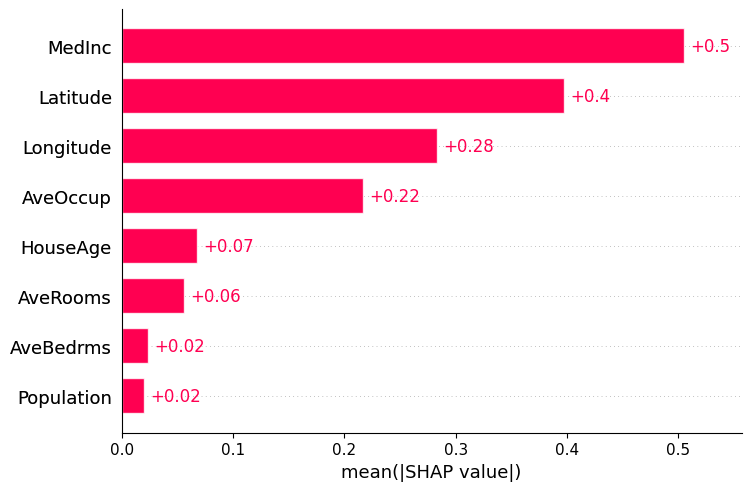

In [ ]:
#SHAP global evaluation
# Plots this view
shap.plots.bar(shap_values)

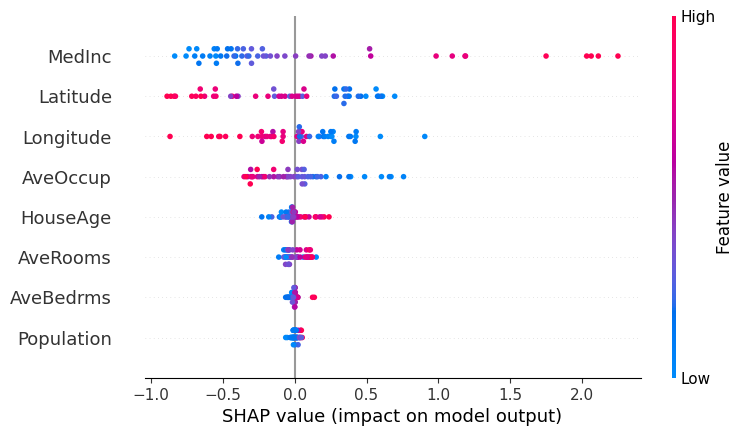

In [ ]:
# Plots the beeswarm
shap.plots.beeswarm(shap_values.sample(50))

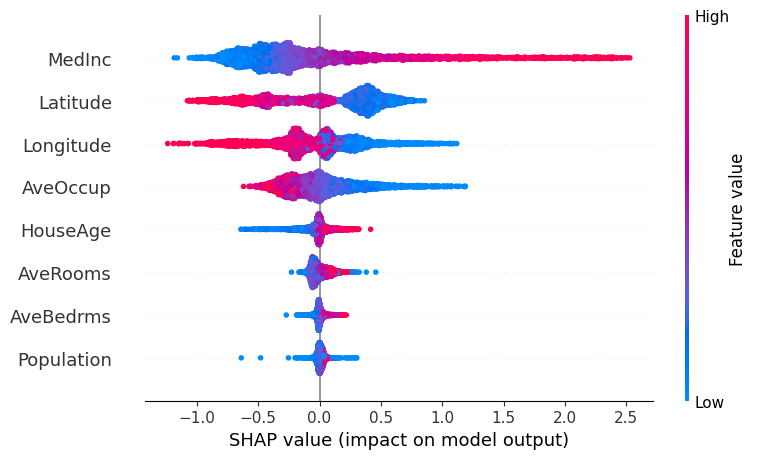

In [ ]:
shap.summary_plot(shap_values)

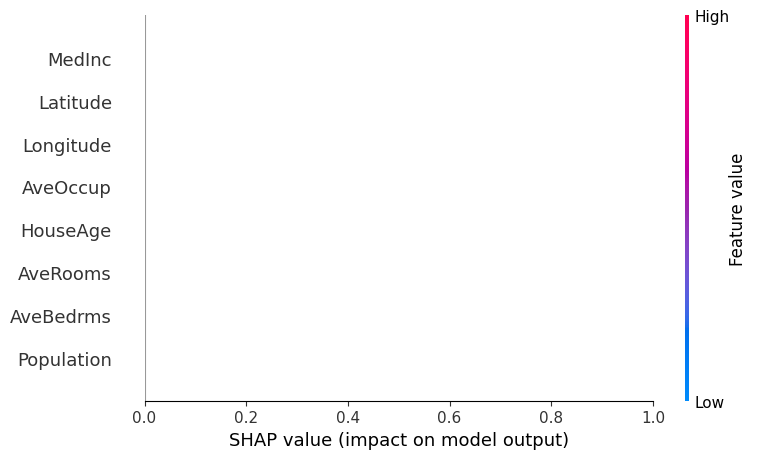

In [ ]:
# Violin plot
shap.summary_plot(shap_values, plot_type= "Violin")

In [ ]:
# Prints the SHAP feature importances
print_feature_importances_shap_values(shap_values,
X_test.columns)

MedInc -> 0.5050 (softmax = 0.1676)
Latitude -> 0.3970 (softmax = 0.1505)
Longitude -> 0.2832 (softmax = 0.1343)
AveOccup -> 0.2165 (softmax = 0.1256)
HouseAge -> 0.0676 (softmax = 0.1082)
AveRooms -> 0.0557 (softmax = 0.1070)
AveBedrms -> 0.0234 (softmax = 0.1036)
Population -> 0.0201 (softmax = 0.1032)


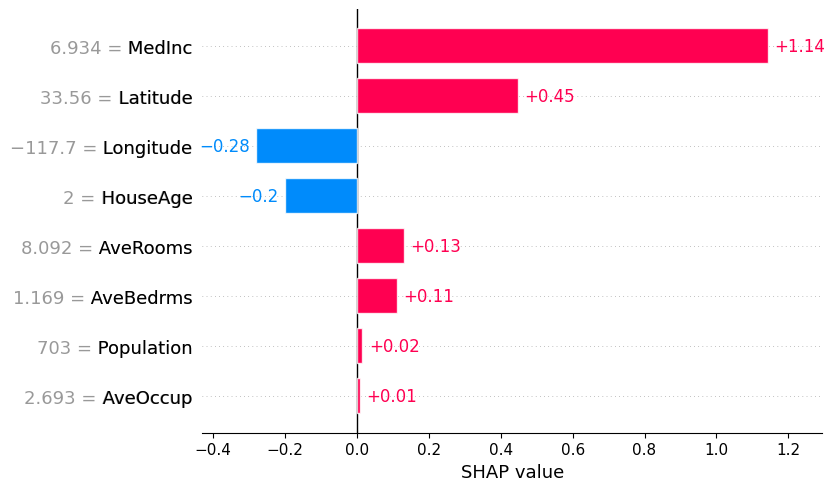

In [ ]:
#SHAP local evaluation
#For a single example
shap.plots.bar(shap_values[0])

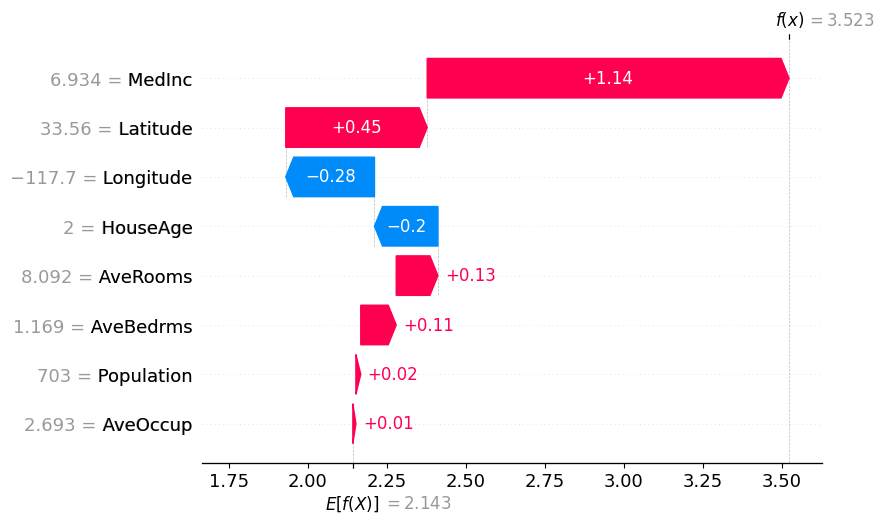

In [ ]:
shap.plots.waterfall(shap_values[0], max_display=10)

In [ ]:
shap.initjs()
shap.plots.force(shap_values[0])